In [2]:
# AI-Powered Customer Churn Analysis

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# Load dataset

df=pd.read_csv('customer_churn_data-raw.csv')
df.head()

,Customer_ID,Gender,Age,Tenure_Months,Contract_Type,Payment_Method,Monthly_Charges,Total_Charges,Internet_Service,Tech_Support,Streaming_Service,Number_of_Complaints,Support_Calls,Last_Login_Days,Satisfaction_Score,Churn
0,C100000,Male,20,62,One Year,Bank Transfer,98.56,6066.68,No Internet,Yes,No,2,0,13,6.4,0
1,C100001,Female,24,4,Month-to-Month,Electronic Check,60.78,232.84,DSL,Yes,No,0,2,25,7.9,1
2,C100002,Female,43,6,Month-to-Month,Electronic Check,103.17,571.54,No Internet,No,Yes,0,5,22,6.3,1
3,C100003,Female,24,72,Month-to-Month,Bank Transfer,68.68,5278.75,DSL,No,Yes,0,2,18,6.1,0
4,C100004,Male,51,16,Month-to-Month,Electronic Check,110.19,1637.33,DSL,No,No,1,3,10,8.2,1


In [4]:
# Basic information

print('Data shape:',df.shape)
print('Columns:',df.columns.tolist())
print('Data types:',df.dtypes)
print('Missing values:',df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


Data shape: (10000, 16)
Columns: ['Customer_ID', 'Gender', 'Age', 'Tenure_Months', 'Contract_Type', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Internet_Service', 'Tech_Support', 'Streaming_Service', 'Number_of_Complaints', 'Support_Calls', 'Last_Login_Days', 'Satisfaction_Score', 'Churn']
Data types: Customer_ID              object
Gender                   object
Age                       int64
Tenure_Months             int64
Contract_Type            object
Payment_Method           object
Monthly_Charges         float64
Total_Charges           float64
Internet_Service         object
Tech_Support             object
Streaming_Service        object
Number_of_Complaints      int64
Support_Calls             int64
Last_Login_Days           int64
Satisfaction_Score      float64
Churn                     int64
dtype: object
Missing values: Customer_ID               0
Gender                    0
Age                       0
Tenure_Months             0
Contract_Type             0
Paym

Data Cleaning

In [5]:
# Make a copy of the raw dataset
churn_df = df.copy()

In [6]:
# Fill missing categorical values
churn_df["Payment_Method"] = churn_df["Payment_Method"].fillna(
    churn_df["Payment_Method"].mode()[0])

In [7]:
# Fill missing numerical values with median
churn_df["Total_Charges"] = churn_df["Total_Charges"].fillna(
    churn_df["Total_Charges"].median())

In [8]:
churn_df["Satisfaction_Score"] = churn_df["Satisfaction_Score"].fillna(
    churn_df["Satisfaction_Score"].median())

In [9]:
print("Missing values after cleaning:")
display(churn_df.isnull().sum())

print("\nDuplicate rows after cleaning:", churn_df.duplicated().sum())

Missing values after cleaning:


Customer_ID             0
Gender                  0
Age                     0
Tenure_Months           0
Contract_Type           0
Payment_Method          0
Monthly_Charges         0
Total_Charges           0
Internet_Service        0
Tech_Support            0
Streaming_Service       0
Number_of_Complaints    0
Support_Calls           0
Last_Login_Days         0
Satisfaction_Score      0
Churn                   0
dtype: int64


Duplicate rows after cleaning: 0


Visualization

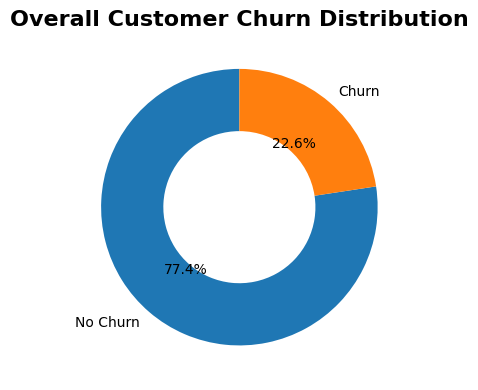

In [10]:
# Churn Distrbution
# Count churn status
churn_counts = df["Churn"].value_counts()

# Create donut chart
plt.figure(figsize=(4,4))

plt.pie(
    churn_counts,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Overall Customer Churn Distribution", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

In [11]:
# Calculate churn rate by contract type
contract_churn = (
    df.groupby("Contract_Type")["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

contract_churn.columns = [
    "Contract_Type",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

# Convert churn rate to percentage
contract_churn["Churn_Rate"] = contract_churn["Churn_Rate"] * 100

contract_churn

,Contract_Type,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-Month,5596,1715,30.646891
1,One Year,2413,354,14.670535
2,Two Year,1991,191,9.593169


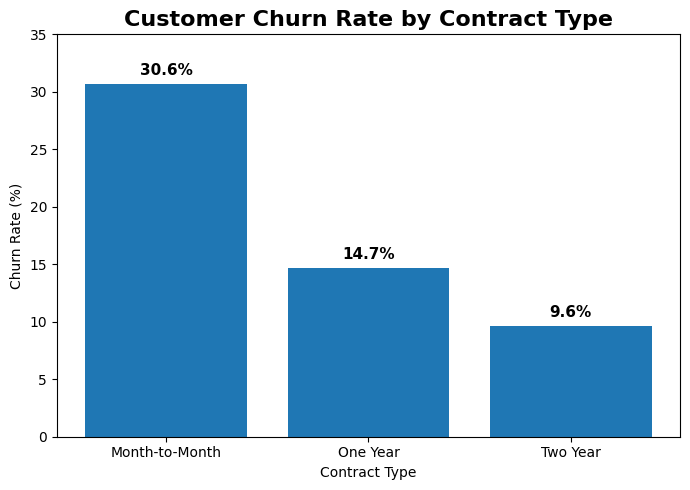

In [12]:
# Customer churn rate by contract type

plt.figure(figsize=(7,5))

bars = plt.bar(
    contract_churn["Contract_Type"],
    contract_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Contract Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 35)

# Add percentage labels
for bar, rate in zip(bars, contract_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [13]:
# churn rate by tenure
# Create a new column for tenure groups

df["Tenure_Group"] = pd.cut(
    df["Tenure_Months"],
    bins=[0, 12, 24, 48, float("inf")],
    labels=["0–12 Months", "13–24 Months", "25–48 Months", "49+ Months"],
    include_lowest=True
)

#Calculate churn rate by tenure group

tenure_churn = (
    df.groupby("Tenure_Group", observed=False)["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

tenure_churn.columns = [
    "Tenure_Group",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

tenure_churn["Churn_Rate"] = tenure_churn["Churn_Rate"] * 100

tenure_churn

,Tenure_Group,Total_Customers,Churned_Customers,Churn_Rate
0,0–12 Months,1646,675,41.008505
1,13–24 Months,1623,538,33.148490
2,25–48 Months,3365,682,20.267459
3,49+ Months,3366,365,10.843731


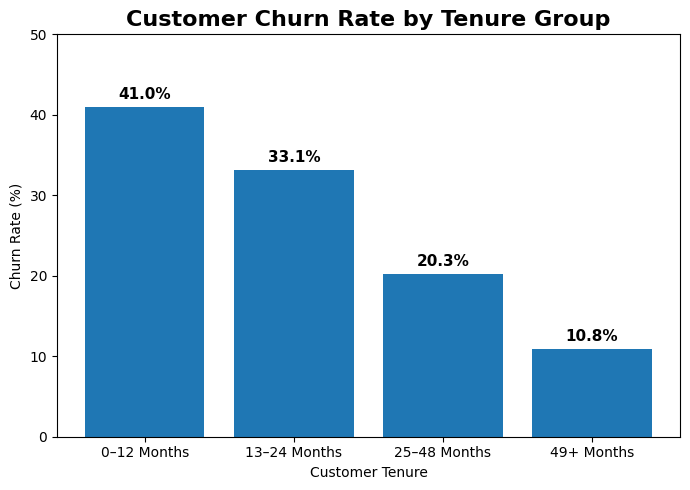

In [14]:
#  Visualizing Customer churn rate by tenure

plt.figure(figsize=(7,5))

bars = plt.bar(
    tenure_churn["Tenure_Group"],
    tenure_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Tenure Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 50)

# Add percentage labels
for bar, rate in zip(bars, tenure_churn["Churn_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [15]:
# Churn rate by number of complaints

# Create complaints groups

df["Complaint_Group"] = pd.cut(
    df["Number_of_Complaints"],
    bins=[-1, 0, 2, 4, float("inf")],
    labels=["No Complaints", "1–2 Complaints", "3–4 Complaints", "5+ Complaints"]
)

# Calculate churn rate by complaint group

complaint_churn = (
    df.groupby("Complaint_Group", observed=False)["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

complaint_churn.columns = [
    "Complaint_Group",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

complaint_churn["Churn_Rate"] *= 100

complaint_churn

,Complaint_Group,Total_Customers,Churned_Customers,Churn_Rate
0,No Complaints,2718,416,15.305372
1,1–2 Complaints,5886,1337,22.714917
2,3–4 Complaints,1277,446,34.925607
3,5+ Complaints,119,61,51.260504


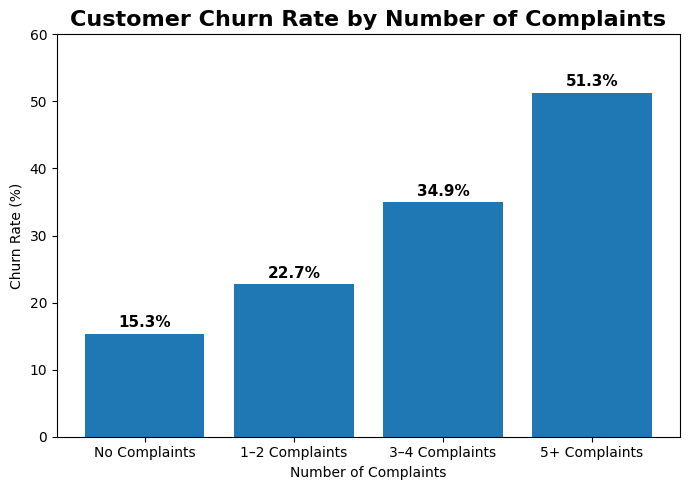

In [16]:
# Customer churn rate by number of complaints

plt.figure(figsize=(7, 5))

bars = plt.bar(
    complaint_churn["Complaint_Group"],
    complaint_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Number of Complaints",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Complaints")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 60)

for bar, rate in zip(
    bars,
    complaint_churn["Churn_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [17]:
# Churn rate by satisfaction score
# Create Satisfaction Score groups

df["Satisfaction_Group"] = pd.cut(
    df["Satisfaction_Score"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# Calculate churn rate by satisfaction group

satisfaction_churn = (
    df.groupby("Satisfaction_Group", observed=False)["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

satisfaction_churn.columns = [
    "Satisfaction_Group",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

satisfaction_churn["Churn_Rate"] *= 100

satisfaction_churn

,Satisfaction_Group,Total_Customers,Churned_Customers,Churn_Rate
0,Low,149,81,54.362416
1,Medium,5659,1558,27.531366
2,High,4092,603,14.736070


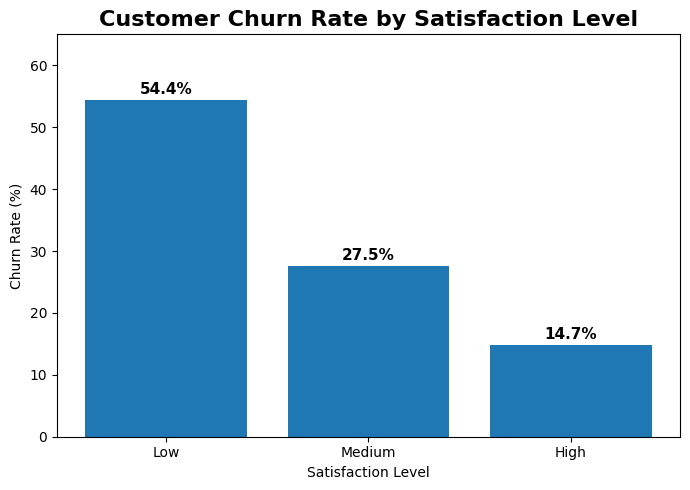

In [18]:
# Customer churn rate by satisfaction score

plt.figure(figsize=(7,5))

bars = plt.bar(
    satisfaction_churn["Satisfaction_Group"],
    satisfaction_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Satisfaction Level",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 65)

for bar, rate in zip(
    bars,
    satisfaction_churn["Churn_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [19]:
# Churn rate by last login activity
# create last login groups

df["Last_Login_Group"] = pd.cut(
    df["Last_Login_Days"],
    bins=[-1, 7, 14, 30, float("inf")],
    labels=["0–7 Days", "8–14 Days", "15–30 Days", "31+ Days"]
)

# Calculate churn

login_churn = (
    df.groupby("Last_Login_Group", observed=False)["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

login_churn.columns = [
    "Last_Login_Group",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

login_churn["Churn_Rate"] *= 100

login_churn


,Last_Login_Group,Total_Customers,Churned_Customers,Churn_Rate
0,0–7 Days,2927,556,18.995559
1,8–14 Days,3486,747,21.428571
2,15–30 Days,3113,806,25.891423
3,31+ Days,474,151,31.856540


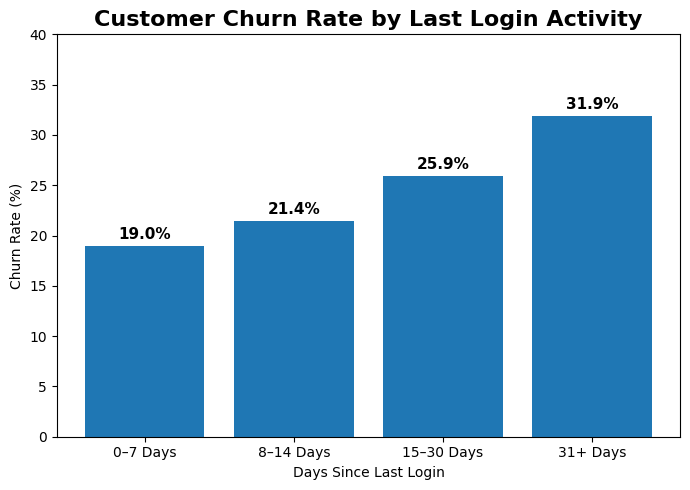

In [20]:
# visualize churn rate by last login activity

plt.figure(figsize=(7,5))

bars = plt.bar(
    login_churn["Last_Login_Group"],
    login_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Last Login Activity",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Days Since Last Login")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 40)

for bar, rate in zip(
    bars,
    login_churn["Churn_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [21]:
# Churn rate by support calls
# create support calls groups

df["Support_Call_Group"] = pd.cut(
    df["Support_Calls"],
    bins=[-1, 0, 2, 5, float("inf")],
    labels=["No Calls", "1–2 Calls", "3–5 Calls", "6+ Calls"]
)

support_churn = (
    df.groupby("Support_Call_Group", observed=False)["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

support_churn.columns = [
    "Support_Call_Group",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

support_churn["Churn_Rate"] *= 100

support_churn

,Support_Call_Group,Total_Customers,Churned_Customers,Churn_Rate
0,No Calls,1113,209,18.778077
1,1–2 Calls,5121,1083,21.148213
2,3–5 Calls,3509,878,25.021374
3,6+ Calls,257,90,35.019455


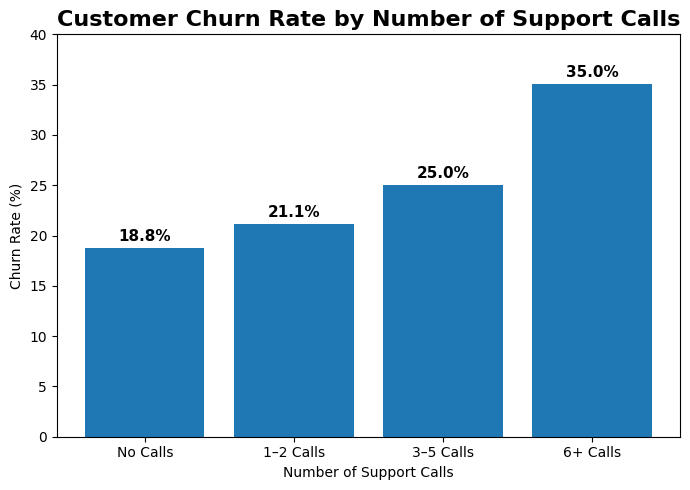

In [22]:
# Visualize churn rate by support calls

plt.figure(figsize=(7,5))

bars = plt.bar(
    support_churn["Support_Call_Group"],
    support_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Number of Support Calls",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Support Calls")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 40)

for bar, rate in zip(
    bars,
    support_churn["Churn_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [23]:
# Churn rate by Monthly Charges
# create monthly charges groups

df["Monthly_Charge_Group"] = pd.cut(
    df["Monthly_Charges"],
    bins=[0, 60, 80, 110, float("inf")],
    labels=["Low", "Medium", "High", "Very High (110+)"],
    include_lowest=True
)

# Calculate churn rate by monthly charges group

charge_churn = (
    df.groupby("Monthly_Charge_Group", observed=False)["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

charge_churn.columns = [
    "Monthly_Charge_Group",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

charge_churn["Churn_Rate"] *= 100

charge_churn

,Monthly_Charge_Group,Total_Customers,Churned_Customers,Churn_Rate
0,Low,1585,217,13.690852
1,Medium,2969,563,18.962614
2,High,4239,1103,26.020288
3,Very High (110+),1207,377,31.234466


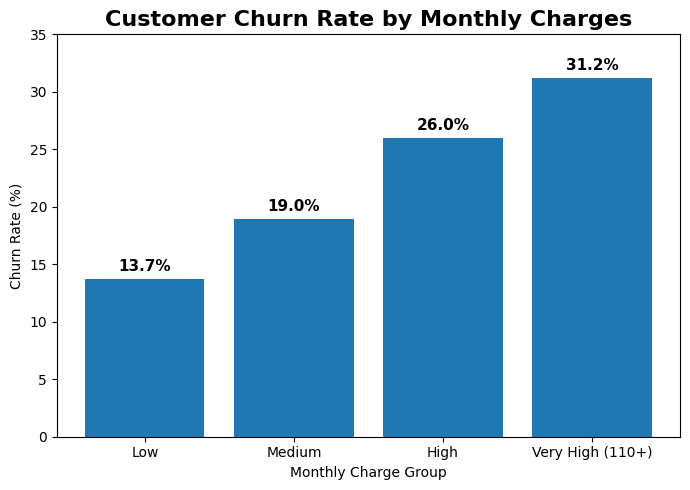

In [24]:
# visualize churn rate by Monthly Charges

plt.figure(figsize=(7,5))

bars = plt.bar(
    charge_churn["Monthly_Charge_Group"],
    charge_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Monthly Charges",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 35)

for bar, rate in zip(
    bars,
    charge_churn["Churn_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [25]:
# Churn rate by Contract Type and Tenure Group
# Create churn by both variables

contract_tenure_churn = (
    df.groupby(
        ["Contract_Type", "Tenure_Group"],
        observed=False
    )["Churn"]
    .mean()
    .reset_index(name="Churn_Rate")
)

contract_tenure_churn["Churn_Rate"] *= 100

contract_tenure_churn

,Contract_Type,Tenure_Group,Churn_Rate
0,Month-to-Month,0–12 Months,52.873563
1,Month-to-Month,13–24 Months,44.493392
2,Month-to-Month,25–48 Months,27.539267
3,Month-to-Month,49+ Months,15.321252
4,One Year,0–12 Months,28.021978
5,One Year,13–24 Months,21.813725
6,One Year,25–48 Months,13.164557
7,One Year,49+ Months,6.933020
8,Two Year,0–12 Months,20.615385
9,Two Year,13–24 Months,14.657980


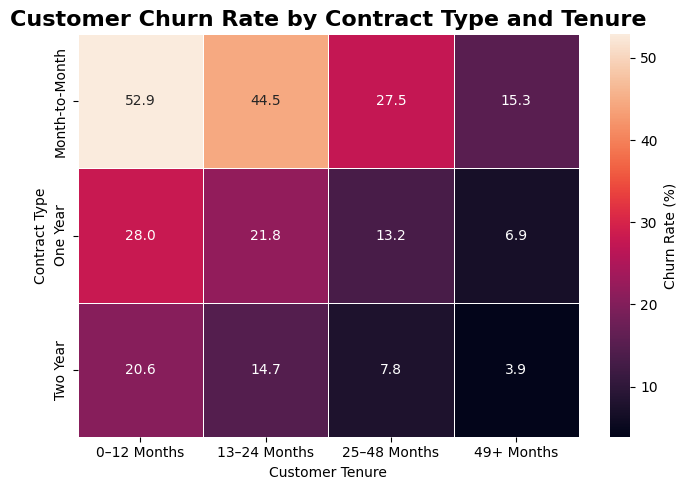

In [26]:
# Create a heatmap to visualize churn rate by contract type and tenure group

import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = contract_tenure_churn.pivot(
    index="Contract_Type",
    columns="Tenure_Group",
    values="Churn_Rate"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title(
    "Customer Churn Rate by Contract Type and Tenure",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Tenure")
plt.ylabel("Contract Type")

plt.tight_layout()
plt.show()

In [27]:
# Churn rate by Internet Service
# Calculate churn rate by internet service type

internet_churn = (
    df.groupby("Internet_Service")["Churn"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

internet_churn.columns = [
    "Internet_Service",
    "Total_Customers",
    "Churned_Customers",
    "Churn_Rate"
]

internet_churn["Churn_Rate"] = (
    internet_churn["Churn_Rate"] * 100
)

internet_churn

,Internet_Service,Total_Customers,Churned_Customers,Churn_Rate
0,DSL,3733,751,20.117868
1,Fiber Optic,4760,1210,25.420168
2,No Internet,1507,299,19.840743


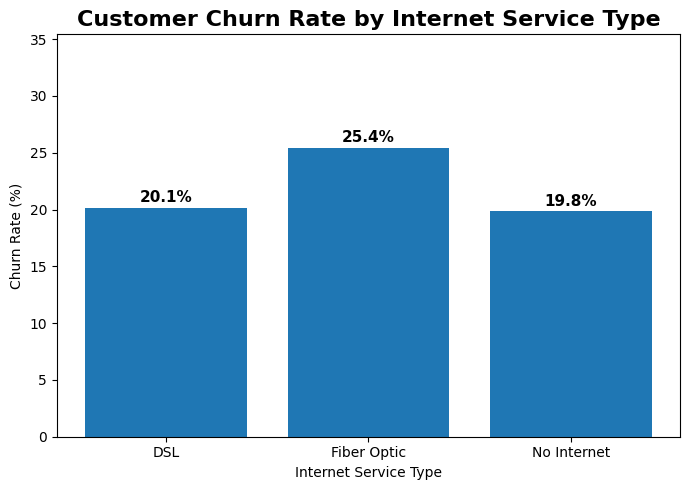

In [28]:
# visualize churn rate by internet service type

plt.figure(figsize=(7,5))

bars = plt.bar(
    internet_churn["Internet_Service"],
    internet_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Internet Service Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, max(internet_churn["Churn_Rate"]) + 10)

# Add percentage labels
for bar, rate in zip(
    bars,
    internet_churn["Churn_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

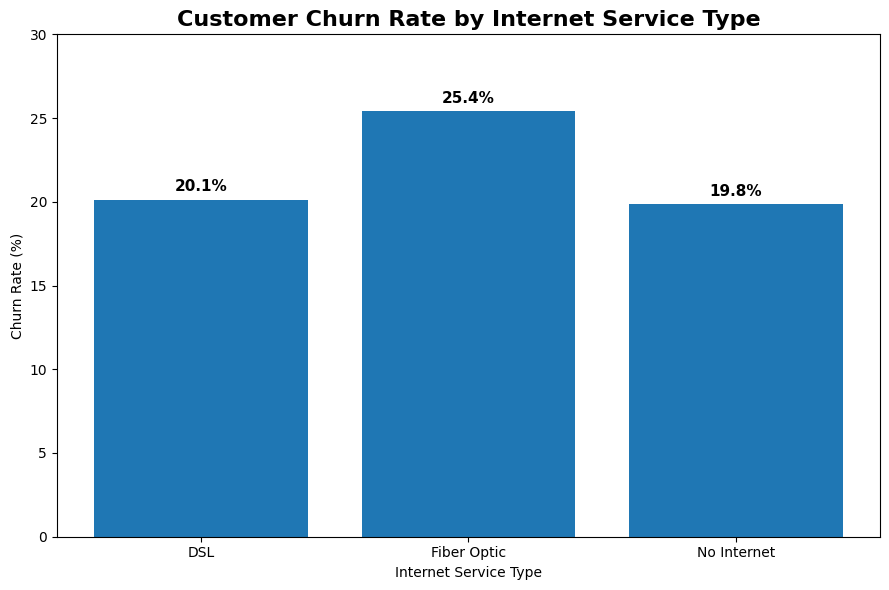

In [29]:
# Visualize churn rate by internet service type
plt.figure(figsize=(9, 6))

bars = plt.bar(
    internet_churn["Internet_Service"],
    internet_churn["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Internet Service Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 30)

# Add percentage labels
for bar, rate in zip(
    bars,
    internet_churn["Churn_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{rate:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()